In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

Simulate data

In [2]:
N = 20
D = 64
T = 8000
SNR = 0.1
random_seed = 42
rng = np.random.default_rng(random_seed)
shared_source = rng.standard_normal((T,))
shared_pattern = rng.standard_normal((D,))
shared_pattern = shared_pattern / np.linalg.norm(shared_pattern)

signal = np.outer(shared_pattern, shared_source)              # shape: (D, T)

# ============================================================
# BUILD EACH SUBJECT'S DATA
# ============================================================

X = np.zeros((N, D, T))

for n in range(N):
    noise_source = rng.standard_normal(T)                     # shape: (T,)
    noise_pattern = rng.standard_normal(D)                    # shape: (D,)
    noise_pattern = noise_pattern / np.linalg.norm(noise_pattern)

    noise = np.outer(noise_pattern, noise_source)             # shape: (D, T)

    X[n, :, :] = signal + (1 / SNR) * noise

print(f"Data shape: {X.shape}")  # should be (20, 64, 10000)

Data shape: (20, 64, 8000)


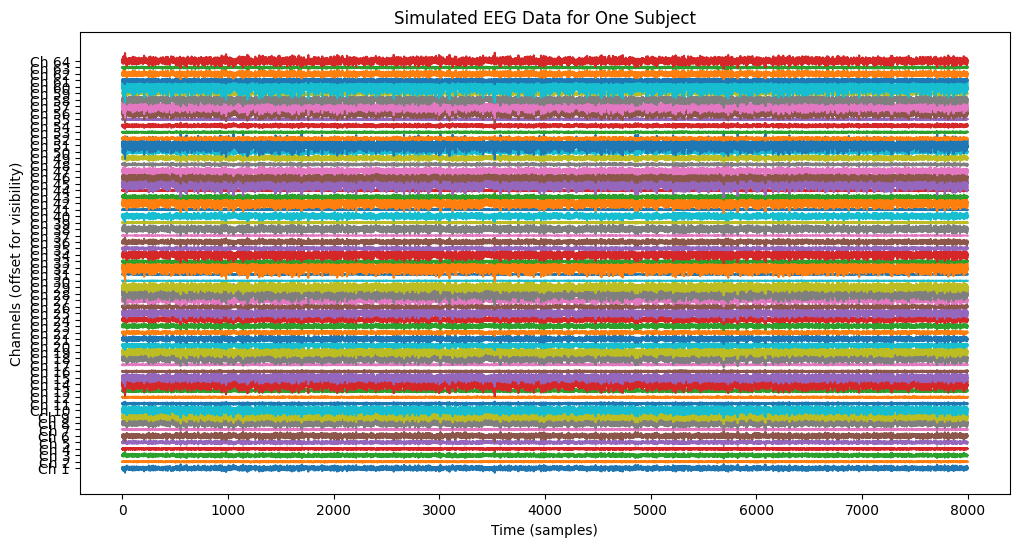

In [3]:
# Plot a single subject's data as lines like an EEG plot
plt.figure(figsize=(12, 6))
for d in range(D):
    plt.plot(X[0, d, :] + d * 5)  # offset each channel for visibility
plt.title("Simulated EEG Data for One Subject")
plt.xlabel("Time (samples)")
plt.ylabel("Channels (offset for visibility)")
plt.yticks(np.arange(0, D * 5, 5), [f"Ch {i+1}" for i in range(D)])
plt.show()

In [4]:
X_mean = np.mean(X, axis=0)  # shape: (D, T)
# Project onto the shared pattern to get the average source estimate
# This is a dot product of the shared pattern with the mean data
shared_source_estimate = shared_pattern @ X_mean  # shape: (T,)

# Correlation between true shared source and its estimate
correlation = np.corrcoef(shared_source, shared_source_estimate)[0, 1]
print(f"\nCorrelation between true shared source and group average estimate: {correlation:.4f}")
print(f"(Should be close to 1.0 if SNR is high enough or N is large enough)")


Correlation between true shared source and group average estimate: 0.9503
(Should be close to 1.0 if SNR is high enough or N is large enough)


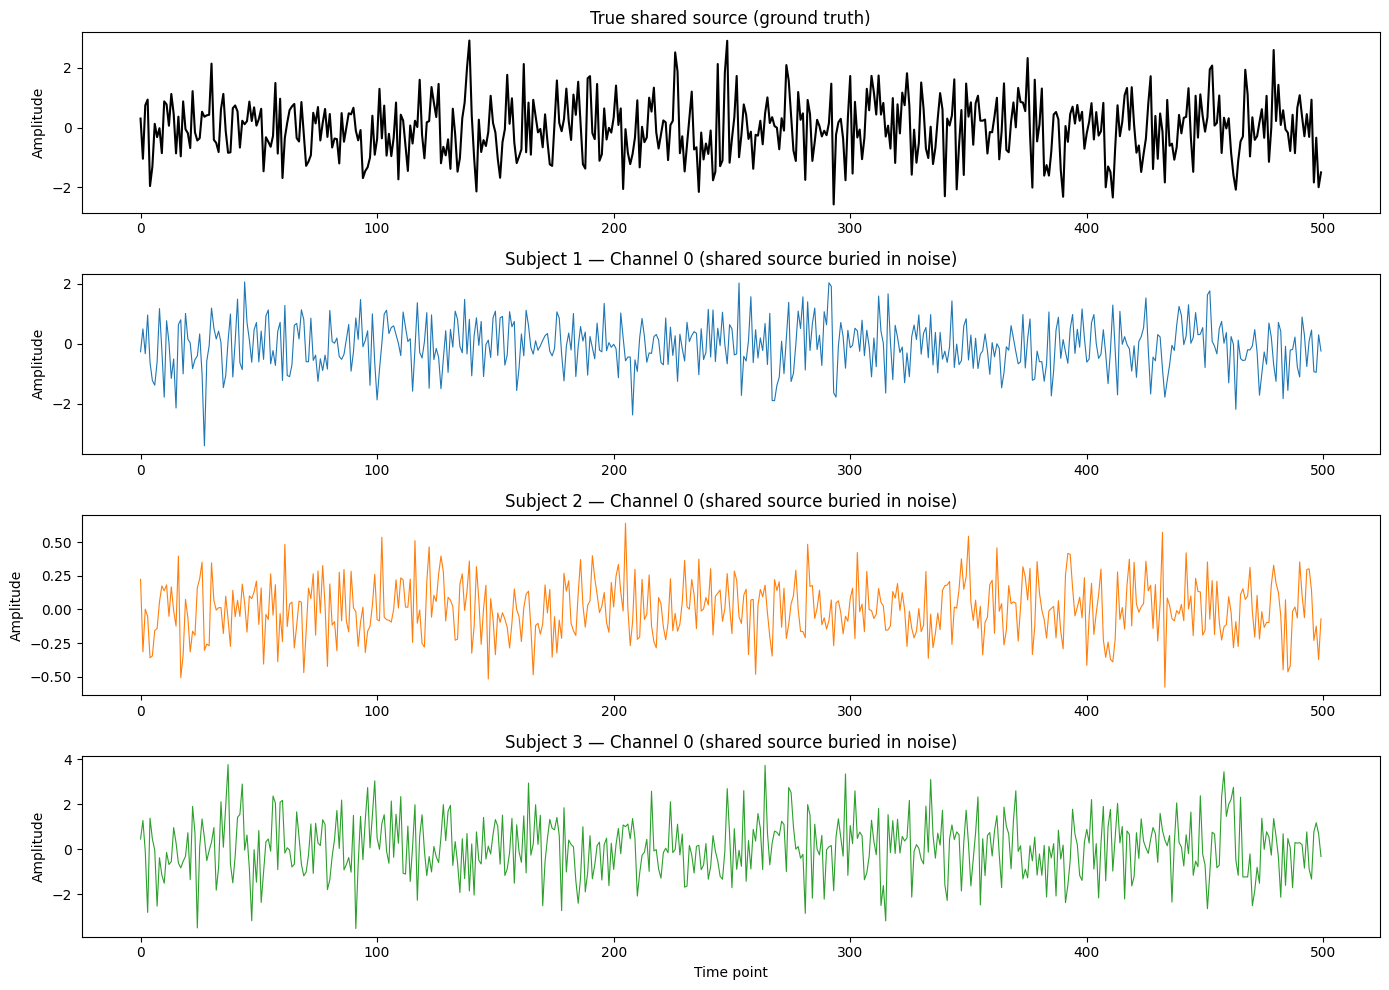


Figure saved: individual_subjects.png


In [5]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
t_plot = np.arange(500)  # plot first 500 time points for clarity

# True shared source
axes[0].plot(t_plot, shared_source[t_plot], color='black', linewidth=1.5)
axes[0].set_title('True shared source (ground truth)')
axes[0].set_ylabel('Amplitude')

# Three individual subjects at channel 0
for i, subj_idx in enumerate([0, 1, 2]):
    axes[i+1].plot(t_plot, X[subj_idx, 0, t_plot], color=f'C{i}', linewidth=0.8)
    axes[i+1].set_title(f'Subject {subj_idx+1} — Channel 0 (shared source buried in noise)')
    axes[i+1].set_ylabel('Amplitude')

axes[-1].set_xlabel('Time point')
plt.tight_layout()
plt.savefig('individual_subjects.png', dpi=150)
plt.show()
print("\nFigure saved: individual_subjects.png")


In [6]:
Rw = sum(np.cov(X[n, :,:]) for n in range(N))

X_mean = np.nanmean(X, axis=0)  # shape: (D, T)
Rt = N**2 * np.cov(X_mean) 

# Walk through

In [7]:
import numpy as np

# Simulate one time point of data for one subject
# 3 channels, one reading each
x = np.array([2.1, -0.5, 1.3])   # one time point, 3 channels

# A set of weights — one per channel
# These are what CorrCA is trying to find
v = np.array([0.6, 0.2, -0.4])

# Apply the linear combination — this is a dot product
# It collapses 3 channel readings into 1 number
y = np.dot(v, x)

print(f"Channel readings:     {x}")
print(f"Weights:              {v}")
print(f"Combined signal:      {y:.4f}")

# Now do this across a full time series
# Simulate 5 time points, 3 channels — shape (3, 5)
X = np.array([
    [2.1,  1.3, -0.2,  0.8,  1.1],   # channel 1
    [-0.5, 0.4,  1.2, -0.3,  0.6],   # channel 2
    [1.3, -0.7,  0.5,  1.0, -0.2],   # channel 3
])

# Apply weights to every time point at once
# v is (3,), X is (3, 5)
# v.T @ X collapses the channel dimension → result is (5,)
Y = v @ X

print(f"\nFull time series shape: {X.shape}")
print(f"After applying weights: {Y.shape}")
print(f"Combined signal over time: {np.round(Y, 4)}")

Channel readings:     [ 2.1 -0.5  1.3]
Weights:              [ 0.6  0.2 -0.4]
Combined signal:      0.6400

Full time series shape: (3, 5)
After applying weights: (5,)
Combined signal over time: [ 0.64  1.14 -0.08  0.02  0.86]


## Step 0: Simulate data

=== SHARED SOURCE ===
Source time series shape:  (1000,)
Spatial pattern shape:     (10,)
Signal contribution shape: (10, 1000)
Shared pattern (how source projects onto each electrode): [ 0.71795816  0.35897908  0.21538745 -0.14359163  0.07179582 -0.07179582
  0.14359163 -0.21538745  0.28718326 -0.35897908]

=== NOISE SOURCES ===
Each subject has a unique noise pattern:
  Subject 1: [-0.169 -0.248  0.162  0.094 -0.524  0.419 -0.035 -0.415  0.444  0.233]
  Subject 2: [ 0.654 -0.098 -0.117  0.033  0.274 -0.157 -0.175  0.293  0.105 -0.567]
  Subject 3: [ 0.074  0.137 -0.513 -0.583 -0.336 -0.365 -0.243  0.24  -0.064  0.074]
  Subject 4: [ 0.337  0.238  0.363 -0.015  0.294 -0.427  0.207 -0.224 -0.479 -0.326]
  Subject 5: [ 0.657 -0.019 -0.414 -0.414  0.239 -0.018  0.27  -0.164  0.256 -0.049]
  Subject 6: [ 0.113  0.385  0.114  0.429  0.197 -0.394  0.57  -0.125  0.327  0.006]

Final data shape: (6, 10, 1000)  (subjects x channels x time)


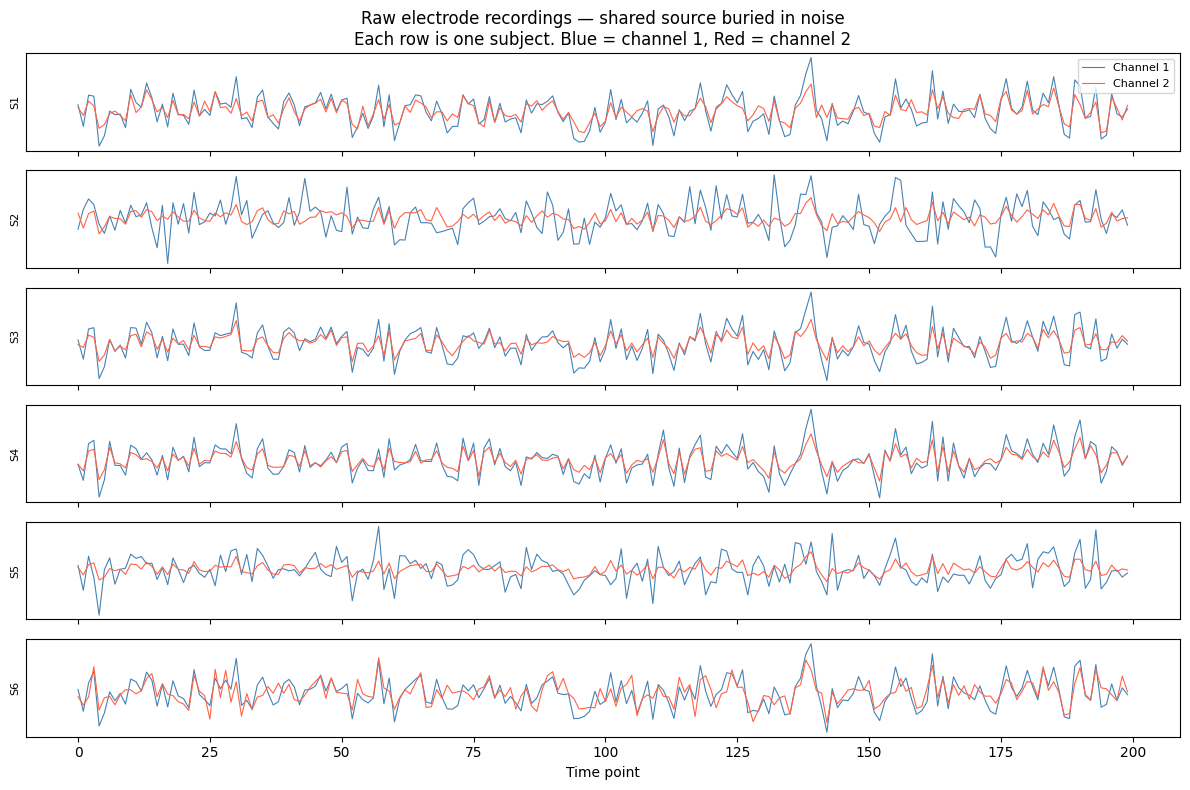

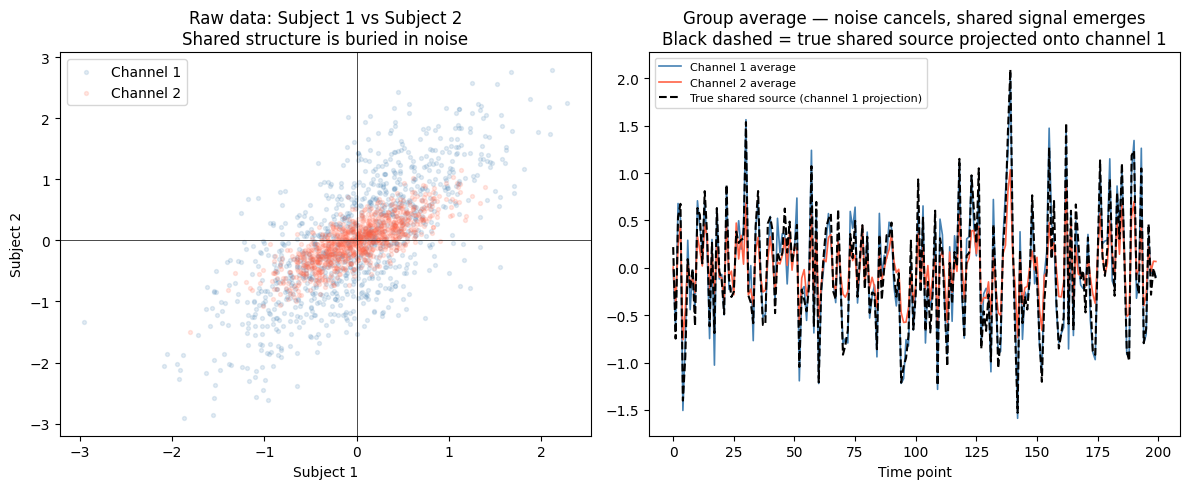


=== HOW BURIED IS THE SHARED SOURCE? ===
Correlation between true shared source and each subject's channel 1:
  Subject 1: r = 0.9723
  Subject 2: r = 0.7338
  Subject 3: r = 0.9949
  Subject 4: r = 0.9031
  Subject 5: r = 0.7256
  Subject 6: r = 0.9871

Correlation with GROUP AVERAGE channel 1: r = 0.9700
(Higher because averaging cancels independent noise)


In [8]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ============================================================
# PARAMETERS
# ============================================================

N = 6       # number of subjects
D = 10      # number of channels (2 so we can visualize easily)
T = 1000    # number of time points
SNR = 1.0   # how strong the shared signal is vs noise

# ============================================================
# STEP 1: THE SHARED SOURCE
# One time series — identical for every subject
# This represents the brain response driven by the stimulus
# ============================================================

shared_source = rng.standard_normal(T)          # shape: (T,)

# The shared source has a spatial pattern — how it projects
# onto each of the D electrodes
# This is the same for every subject (key assumption of CorrCA)
shared_pattern = np.array([1.0, 0.5, 0.3, -0.2, 0.1, -0.1, 0.2, -0.3, 0.4, -0.5])           # shape: (D,)
shared_pattern = shared_pattern / np.linalg.norm(shared_pattern)

# The shared source's contribution to the electrode recordings
# outer product: (D,) x (T,) → (D, T)
signal = np.outer(shared_pattern, shared_source)

print("=== SHARED SOURCE ===")
print(f"Source time series shape:  {shared_source.shape}")
print(f"Spatial pattern shape:     {shared_pattern.shape}")
print(f"Signal contribution shape: {signal.shape}")
print(f"Shared pattern (how source projects onto each electrode): {shared_pattern}")

# ============================================================
# STEP 2: THE NOISE SOURCE
# Each subject has their own private noise time series
# AND their own private spatial pattern
# ============================================================

X = np.zeros((N, D, T))
noise_sources   = np.zeros((N, T))
noise_patterns  = np.zeros((N, D))

for n in range(N):
    # Unique noise time series for this subject
    noise_source = rng.standard_normal(T)
    noise_sources[n] = noise_source

    # Unique spatial pattern for this subject's noise
    noise_pattern = rng.standard_normal(D)
    noise_pattern = noise_pattern / np.linalg.norm(noise_pattern)
    noise_patterns[n] = noise_pattern

    # Noise contribution: outer product → (D, T)
    noise = np.outer(noise_pattern, noise_source)

    # Mix signal and noise according to SNR
    # Lower SNR = noise dominates = harder to find shared signal
    X[n] = signal + (1 / SNR) * noise

print("\n=== NOISE SOURCES ===")
print(f"Each subject has a unique noise pattern:")
for n in range(N):
    print(f"  Subject {n+1}: {np.round(noise_patterns[n], 3)}")

print(f"\nFinal data shape: {X.shape}  (subjects x channels x time)")

# ============================================================
# STEP 3: VISUALIZE WHAT EACH SUBJECT'S DATA LOOKS LIKE
# ============================================================

fig, axes = plt.subplots(N, 1, figsize=(12, 8), sharex=True)
t = np.arange(200)  # plot first 200 time points

for n in range(N):
    axes[n].plot(t, X[n, 0, :200], color='steelblue',
                 linewidth=0.8, label='Channel 1')
    axes[n].plot(t, X[n, 1, :200], color='tomato',
                 linewidth=0.8, label='Channel 2')
    axes[n].set_ylabel(f'S{n+1}', fontsize=8)
    axes[n].set_yticks([])

axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_title(
    'Raw electrode recordings — shared source buried in noise\n'
    'Each row is one subject. Blue = channel 1, Red = channel 2'
)
axes[-1].set_xlabel('Time point')
plt.tight_layout()
plt.savefig('raw_recordings.png', dpi=150)
plt.show()

# ============================================================
# STEP 4: VISUALIZE THE SCATTER PLOT
# This is Figure 1C in the paper
# Plot subject 1 vs subject 2 at each time point
# X-axis = subject 1's channel readings
# Y-axis = subject 2's channel readings
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Before CorrCA: scatter of raw channel data ---
ax = axes[0]
ax.scatter(X[0, 0, :], X[1, 0, :],
           alpha=0.15, s=8, color='steelblue', label='Channel 1')
ax.scatter(X[0, 1, :], X[1, 1, :],
           alpha=0.15, s=8, color='tomato', label='Channel 2')
ax.set_xlabel('Subject 1')
ax.set_ylabel('Subject 2')
ax.set_title('Raw data: Subject 1 vs Subject 2\n'
             'Shared structure is buried in noise')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

# --- Group average: noise cancels out, signal emerges ---
ax = axes[1]
X_mean = np.mean(X, axis=0)   # average across subjects → (D, T)
ax.plot(np.arange(200), X_mean[0, :200],
        color='steelblue', linewidth=1.2, label='Channel 1 average')
ax.plot(np.arange(200), X_mean[1, :200],
        color='tomato', linewidth=1.2, label='Channel 2 average')
ax.plot(np.arange(200), shared_source[:200] * shared_pattern[0],
        color='black', linewidth=1.5, linestyle='--',
        label='True shared source (channel 1 projection)')
ax.set_title('Group average — noise cancels, shared signal emerges\n'
             'Black dashed = true shared source projected onto channel 1')
ax.set_xlabel('Time point')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('scatter_and_average.png', dpi=150)
plt.show()

# ============================================================
# STEP 5: QUANTIFY HOW MUCH THE NOISE BURIES THE SIGNAL
# Correlation between true shared source and each subject's
# raw channel 1 recording — should be low before CorrCA
# ============================================================

print("\n=== HOW BURIED IS THE SHARED SOURCE? ===")
print("Correlation between true shared source and each subject's channel 1:")
for n in range(N):
    r = np.corrcoef(shared_source, X[n, 0, :])[0, 1]
    print(f"  Subject {n+1}: r = {r:.4f}")

r_mean = np.mean(X_mean[0, :])
r_avg  = np.corrcoef(shared_source,
                     X_mean[0, :])[0, 1]
print(f"\nCorrelation with GROUP AVERAGE channel 1: r = {r_avg:.4f}")
print("(Higher because averaging cancels independent noise)")


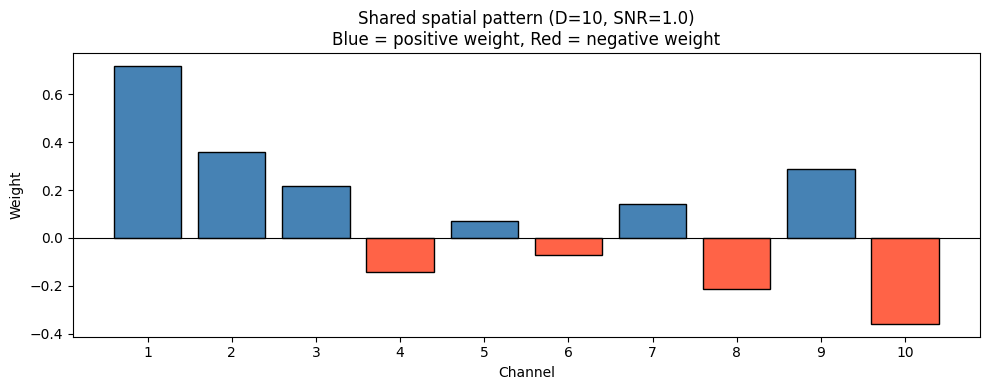

In [9]:
# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['steelblue' if w >= 0 else 'tomato' for w in shared_pattern]
bars = ax.bar(range(1, D+1), shared_pattern, color=colors, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Channel')
ax.set_ylabel('Weight')
ax.set_title(f'Shared spatial pattern (D={D}, SNR={SNR})\n'
             f'Blue = positive weight, Red = negative weight')
ax.set_xticks(range(1, D+1))
plt.tight_layout()
plt.show()

## STEP 1: APPLY a projection vector
Before computing ISC, we need to project the data from D channels down to a single time series per subject. 
We will use a known good weight vector first (the true shared pattern), then a bad one to compare

In [10]:
v_good = shared_pattern.copy()
v_random = rng.standard_normal(D)
v_random = v_random / np.linalg.norm(v_random)


def project(X, v):

    """Apply projection vector v to data X
    
    Parameters
    ----------
    X : ndarray, shape (N, D, T)
        Data array where N is the number of subjects, D is the number of channels, and T is the number of time points.
    v : ndarray, shape (D,)
        Projection vector.

    Returns
    -------
    projected : ndarray, shape (N, T)
        Projected data for each subject (one time series per subject    ).
    """
    N, D, T = X.shape
    projected = np.zeros((N, T))
    for n in range(N):
        projected[n] = v @ X[n]
    return projected

Y_good   = project(X, v_good)
Y_random = project(X, v_random)

print("=== PROJECTED DATA SHAPES ===")
print(f"Y_good shape:   {Y_good.shape}   (subjects x time)")
print(f"Y_random shape: {Y_random.shape} (subjects x time)")

=== PROJECTED DATA SHAPES ===
Y_good shape:   (6, 1000)   (subjects x time)
Y_random shape: (6, 1000) (subjects x time)


## STEP 2: DEMEAN EACH SUBJECT'S PROJECTED TIME SERIES
 Before computing covariance we subtract each subject's
 personal mean — the same demeaning step from the
 covariance formula we discussed earlier


In [11]:


def demean(Y):
    """
    Subtract each subject's mean from their time series.

    Parameters
    ----------
    Y : np.array, shape (N, T)

    Returns
    -------
    Y_dm : np.array, shape (N, T)
    """
    # Mean across time for each subject → shape (N, 1)
    # keepdims=True keeps the shape compatible for subtraction
    subject_means = np.mean(Y, axis=1, keepdims=True)
    Y_dm = Y - subject_means
    return Y_dm

Y_good_dm   = demean(Y_good)
Y_random_dm = demean(Y_random)

print("\n=== DEMEANING CHECK ===")
print("Mean of each subject's signal after demeaning (should be ~0):")
print(np.round(np.mean(Y_good_dm, axis=1), 10))



=== DEMEANING CHECK ===
Mean of each subject's signal after demeaning (should be ~0):
[ 0.  0. -0. -0. -0. -0.]


## Step 3: Compute R_kl

r_kl is the covariance between subject k and subject l. It measures how much their signals move together. 

Formula:  

$r_{kl} = \sum_{t=1}^T{(y^{k}_t - \bar{k})(y^{l}_t - \bar{l})}$

In [12]:
def compute_r_kl(Y_dm, k, l):
    """
    Compute the correlation r_kl between subject k and subject l.

    Parameters
    ----------
    Y_dm : np.array, shape (N, T)
        Demeaned projected data for N subjects and T time points.
    k : int
        Index of subject k (0-based).
    l : int
        Index of subject l (0-based).

    Returns
    -------
    r_kl : float
        Correlation between subject k and subject l.
    """
    running_sum = 0
    for t in range(Y_dm.shape[1]):
        running_sum += Y_dm[k, t] * Y_dm[l, t]
    return running_sum

# Demonstrate r_kl for a few pairs
print("\n=== r_kl VALUES (GOOD PROJECTION) ===")
print("Covariance between pairs of subjects:")
for k in range(3):
    for l in range(3):
        r = compute_r_kl(Y_good_dm, k, l)
        label = "(self)" if k == l else ""
        print(f"  r_{k+1}{l+1} = {r:.2f}  {label}")

print("\nNote: diagonal (self-covariance) = each subject's own variance")
print("      off-diagonal = shared covariance between subjects")


=== r_kl VALUES (GOOD PROJECTION) ===
Covariance between pairs of subjects:
  r_11 = 996.67  (self)
  r_12 = 987.64  
  r_13 = 977.75  
  r_21 = 987.64  
  r_22 = 1346.21  (self)
  r_23 = 986.93  
  r_31 = 977.75  
  r_32 = 986.93  
  r_33 = 979.38  (self)

Note: diagonal (self-covariance) = each subject's own variance
      off-diagonal = shared covariance between subjects


## Step 4: Build full covariance matrix
compute r_kl for every pair of subject. result is NxN matrix

In [13]:
def compute_covariance_matrix_subjects(Y_dm):
    """
    Compute the full (N x N) pairwise covariance matrix
    across all subjects.

    Parameters
    ----------
    Y_dm : np.array, shape (N, T)

    Returns
    -------
    R : np.array, shape (N, N)
        R[k, l] = covariance between subject k and subject l
    """
    N = Y_dm.shape[0]
    R = np.zeros((N, N))
    for k in range(N):
        for l in range(N):
            R[k,l] = compute_r_kl(Y_dm, k, l)
    return R


=== PAIRWISE COVARIANCE MATRIX (GOOD PROJECTION) ===
[[ 996.7  987.6  977.8  979.6  974.9  992.2]
 [ 987.6 1346.2  986.9  999.7 1003.4  992.4]
 [ 977.8  986.9  979.4  975.8  974.3  989.7]
 [ 979.6  999.7  975.8 1245.1  999.8  979.1]
 [ 974.9 1003.4  974.3  999.8 1365.6  972.9]
 [ 992.2  992.4  989.7  979.1  972.9 1192.1]]

Diagonal = within-subject variance
Off-diagonal = between-subject covariance


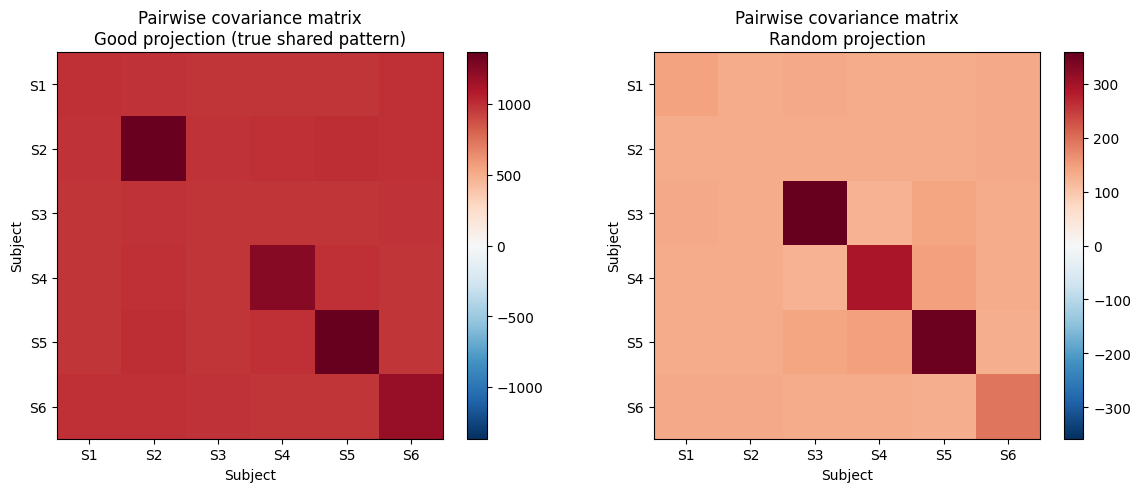

In [14]:
R_good   = compute_covariance_matrix_subjects(Y_good_dm)
R_random = compute_covariance_matrix_subjects(Y_random_dm)

print("\n=== PAIRWISE COVARIANCE MATRIX (GOOD PROJECTION) ===")
print(np.round(R_good, 1))
print("\nDiagonal = within-subject variance")
print("Off-diagonal = between-subject covariance")

# Visualize both covariance matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, R, title in zip(axes,
                         [R_good, R_random],
                         ['Good projection (true shared pattern)',
                          'Random projection']):
    im = ax.imshow(R, cmap='RdBu_r',
                   vmin=-np.max(np.abs(R)),
                   vmax=np.max(np.abs(R)))
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f'Pairwise covariance matrix\n{title}')
    ax.set_xlabel('Subject')
    ax.set_ylabel('Subject')
    ax.set_xticks(range(N))
    ax.set_yticks(range(N))
    ax.set_xticklabels([f'S{n+1}' for n in range(N)])
    ax.set_yticklabels([f'S{n+1}' for n in range(N)])

plt.tight_layout()
plt.savefig('covariance_matrices.png', dpi=150)
plt.show()

## Step 5: Compute r_B and R_w from the covariance matrix

r_W = sum of diagonal entries (within-subject variance). 

r_B = sum of off-diagonal entries (between-subjectn covariance)

In [15]:
def compute_rB_rW(R):
    """
    Compute rB and rW from the covariance matrix R.

    Parameters
    ----------
    R : np.array, shape (N, N)
        Pairwise covariance matrix across subjects.

    Returns
    -------
    rB : float
        Average between-subject covariance.
    rW : float
        Average within-subject variance.
    """
    
    N = R.shape[0]
    r_w = 0
    r_b = 0
    for k in range(N):
        for l in range(N):
            if k == l:
                r_w += R[k,l]
            else:
                r_b += R[k,l]
    return r_b, r_w

r_B_good, r_W_good = compute_rB_rW(R_good)
r_B_random, r_W_random = compute_rB_rW(R_random)

print("\n=== r_B AND r_W ===")
print(f"Good projection:   r_B = {r_B_good:.2f},  r_W = {r_W_good:.2f}")
print(f"Random projection: r_B = {r_B_random:.2f}, r_W = {r_W_random:.2f}")




=== r_B AND r_W ===
Good projection:   r_B = 29572.53,  r_W = 7125.08
Random projection: r_B = 4015.50, r_W = 1471.91


## Step 6: Compute ISC


equation 2 in Parra, Haufel, Dmochowski, 2019.  


$ISC = (\frac{1}{N - 1}) * (\frac{R_B}{R_W})$

In [16]:

def compute_ISC(r_B, r_W, N):
    """
    Compute Inter-Subject Correlation.

    Formula (equation 2 in the paper):
    ISC = (1 / N-1) * (r_B / r_W)

    Parameters
    ----------
    r_B : float
        Between-subject covariance
    r_W : float
        Within-subject covariance
    N   : int
        Number of subjects

    Returns
    -------
    float
        ISC value
    """
    return (1 / (N - 1)) * (r_B / r_W)

ISC_good   = compute_ISC(r_B_good,   r_W_good,   N)
ISC_random = compute_ISC(r_B_random, r_W_random, N)

print("\n=== ISC VALUES ===")
print(f"Good projection (true shared pattern): ISC = {ISC_good:.4f}")
print(f"Random projection:                     ISC = {ISC_random:.4f}")
print(f"\nThe good projection gives much higher ISC.")
print(f"CorrCA's job is to find the projection that maximizes this value.")



=== ISC VALUES ===
Good projection (true shared pattern): ISC = 0.8301
Random projection:                     ISC = 0.5456

The good projection gives much higher ISC.
CorrCA's job is to find the projection that maximizes this value.


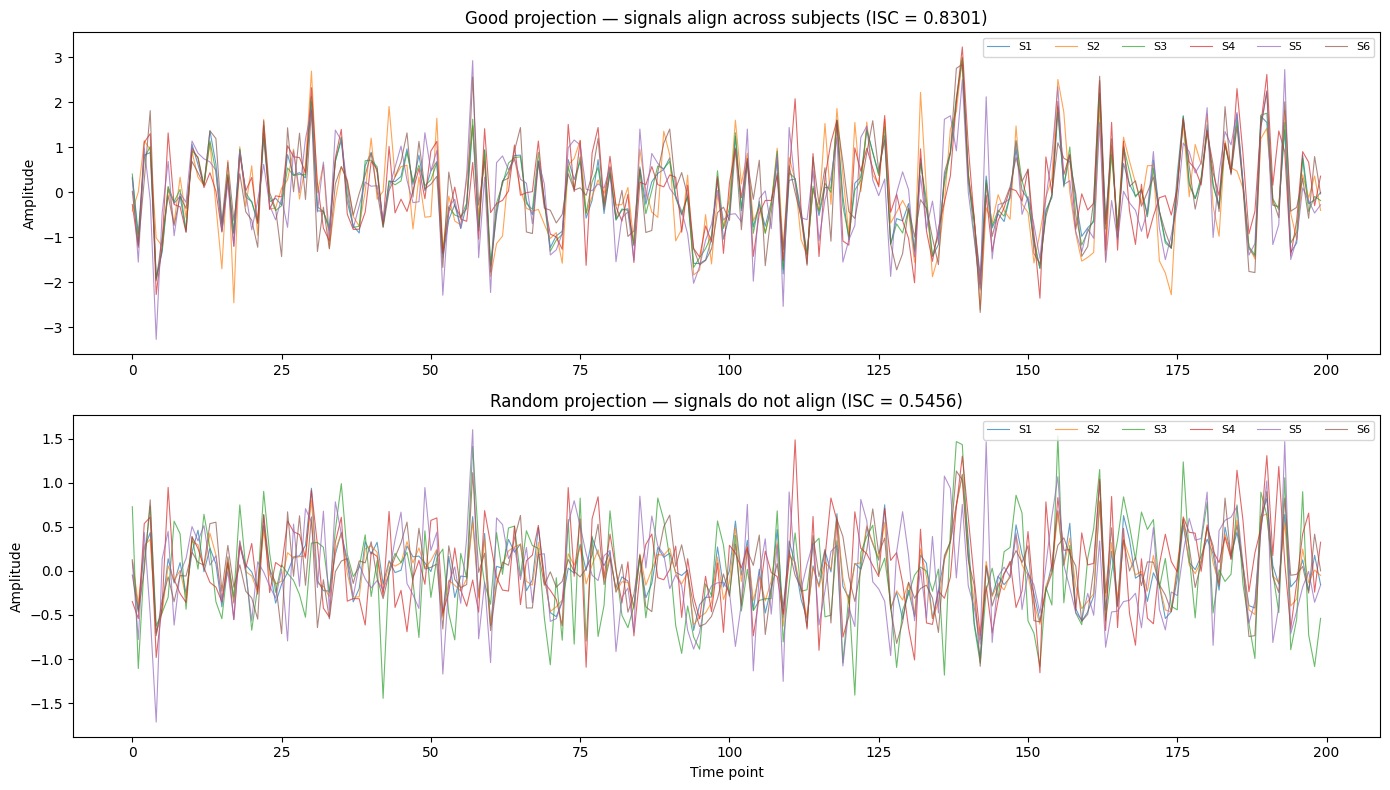

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
t_plot = np.arange(200)

for n in range(N):
    axes[0].plot(t_plot, Y_good_dm[n, :200],
                 linewidth=0.8, alpha=0.7, label=f'S{n+1}')
axes[0].set_title(f'Good projection — signals align across subjects '
                  f'(ISC = {ISC_good:.4f})')
axes[0].set_ylabel('Amplitude')
axes[0].legend(loc='upper right', fontsize=8, ncol=N)

for n in range(N):
    axes[1].plot(t_plot, Y_random_dm[n, :200],
                 linewidth=0.8, alpha=0.7, label=f'S{n+1}')
axes[1].set_title(f'Random projection — signals do not align '
                  f'(ISC = {ISC_random:.4f})')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time point')
axes[1].legend(loc='upper right', fontsize=8, ncol=N)

plt.tight_layout()
plt.show()

# MATRIX FORM

## Step 0: Simulate

In [ ]:
rng = np.random.default_rng(42)

# ============================================================
# REBUILD SIMULATION DATA
# ============================================================

N   = 20      # more subjects = better recovery
D   = 64      # channels
T   = 10000   # time points
SNR = 1.0     # signal to noise ratio

# shared source is a sine wave with some noise
#shared_source = np.sin(np.linspace(0, 20 * np.pi, T)) + 0.1 * rng.standard_normal(T)
shared_source  = rng.standard_normal(T)
shared_pattern = rng.standard_normal(D)
shared_pattern = shared_pattern / np.linalg.norm(shared_pattern)
signal         = np.outer(shared_pattern, shared_source)

X = np.zeros((N, D, T))
for n in range(N):
    noise_source  = rng.standard_normal(T)
    noise_pattern = rng.standard_normal(D)
    noise_pattern = noise_pattern / np.linalg.norm(noise_pattern)
    X[n]          = signal + (1 / SNR) * np.outer(noise_pattern, noise_source)

print(f"Data shape: {X.shape}  (subjects x channels x time)")

# Visualize the shared pattern
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['steelblue' if w >= 0 else 'tomato' for w in shared_pattern]
bars = ax.bar(range(1, D+1), shared_pattern, color=colors, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Channel')
ax.set_ylabel('Weight')
ax.set_title(f'Shared spatial pattern (D={D}, SNR={SNR})\n'
             f'Blue = positive weight, Red = negative weight')
ax.set_xticks(range(1, D+1))
plt.tight_layout()
plt.show()

## Step1: Compute Rw - Within-Subject Covariance Matrix

For each subject, compute their (D xD) covariance matrix. Then sum across all subjects

In [ ]:
def compute_Rw(X):
    """
    Compute the within-subject covariance matrix Rw.

    Parameters
    ----------
    X : np.array, shape (N, D, T)
        Data array where N is the number of subjects, D is the number of channels, and T is the number of time points.

    Returns
    -------
    Rw : np.array, shape (D, D)
        Within-subject covariance matrix.
    """
    N = X.shape[0]
    Rw = np.zeros((X.shape[1], X.shape[1]))
    for n in range(N):
        Rw += np.cov(X[n])
    return Rw

Rw = compute_Rw(X)

print("\n=== WITHIN-SUBJECT COVARIANCE MATRIX Rw ===")
print(f"Shape: {Rw.shape}")
print(f"Diagonal (channel variances, first 5): "
      f"{np.round(np.diag(Rw)[:5], 2)}")
print(f"This captures how channels co-vary WITHIN each subject")

 ## Step 2: Compute Rt - Total Covariance Matrix
 Using the fast method from section 2.2 of the paper

 - Step 2a: Average data across subjects at each time point 
  X_mean shape: (D, T)
- Step 2b: Compute covariance of this averaged signal
- Step 2c: Scale by N^2 to correct for the averaging

 $R_t = N^2 * cov(\text{mean across subjects})$

In [ ]:


def compute_Rt(X):
    """
    Compute total covariance matrix using the fast method.
    Avoids explicit pairwise subject comparisons.

    Parameters
    ----------
    X : np.array, shape (N, D, T)

    Returns
    -------
    Rt : np.array, shape (D, D)
    """
    N, D, T = X.shape

    # Average across subjects → shape (D, T)
    # Shared signal survives, independent noise cancels
    X_mean = np.mean(X, axis=0)

    # Covariance of the averaged signal, scaled by N^2
    Rt = N**2 * np.cov(X_mean)

    return Rt

Rt = compute_Rt(X)

print("\n=== TOTAL COVARIANCE MATRIX Rt ===")
print(f"Shape: {Rt.shape}")
print(f"Diagonal (first 5): {np.round(np.diag(Rt)[:5], 2)}")

## Step 3: Compute Rb - Between-subject covariance Matrix

$R_b = \frac{(R_t - R_w)}{(N-1)}$ 


This isolated the covariance that is shared across subject by removing the within-subject covariance from the total

In [ ]:
def compute_Rb(Rt, Rw, N):
    """
    Compute between-subject covariance matrix Rb.

    Parameters
    ----------
    Rt : np.array, shape (D, D)
        Total covariance matrix.
    Rw : np.array, shape (D, D)
        Within-subject covariance matrix.

    Returns
    -------
    Rb : np.array, shape (D, D)
        Between-subject covariance matrix.
    """
    return (Rt - Rw) / (N - 1) 

Rb = compute_Rb(Rt, Rw, N)

print("\n=== BETWEEN-SUBJECT COVARIANCE MATRIX Rb ===")
print(f"Shape: {Rb.shape}")
print(f"Diagonal (first 5): {np.round(np.diag(Rb)[:5], 2)}")
print(f"\nNote: Rb values should be smaller than Rw values")
print(f"They represent only the shared part of the signal")

In [ ]:
# Visualize all three matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, R, title in zip(axes,
                         [Rw, Rt, Rb],
                         ['Rw (within-subject)',
                          'Rt (total)',
                          'Rb (between-subject)']):
    vmax = np.max(np.abs(R))
    im = ax.imshow(R, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f'{title}\nshape: {R.shape}')
    ax.set_xlabel('Channel')
    ax.set_ylabel('Channel')

plt.tight_layout()
#plt.savefig('covariance_matrices_DxD.png', dpi=150)
plt.show()



## Step 4: Regularization

Before solving the eigenvalue problem we stabilize Rw by adding a small amount to it's diagonal.  
This prevents numerical instability when inverting Rw.


_Rw_reg = (1 - gamma) * Rw + gamma * mean(diag(Rw)) * I_. 


 - gamma = 0 → no regularization (use raw Rw). 
 - gamma = 1 → fully replace with scaled identity matrix. 
 - gamma = 0.1 → 90% original, 10% stabilization

In [ ]:
def regularize(Rw, gamma=0.1):
    """
    Apply Tikhonov regularization to Rw.

    Parameters
    ----------
    Rw    : np.array, shape (D, D)
    gamma : float, regularization strength

    Returns
    -------
    Rw_reg : np.array, shape (D, D)
    """
    D = Rw.shape[0]
    # Mean of diagonal = average channel variance
    mean_var = np.mean(np.diag(Rw))
    Rw_reg   = (1 - gamma) * Rw + gamma * mean_var * np.identity(D)
    return Rw_reg

gamma  = 0.1
Rw_reg = regularize(Rw, gamma)

print(f"\n=== REGULARIZATION ===")
print(f"Gamma = {gamma}")
print(f"Mean diagonal before: {np.mean(np.diag(Rw)):.4f}")
print(f"Mean diagonal after:  {np.mean(np.diag(Rw_reg)):.4f}")
print(f"Off-diagonal slightly shrunk toward zero for stability")

## Step 5: Solve the generalized eigenvalue problem.
equation 8 in Parra, Haufel, Dmochowski, 2019.  

Find all $v$ and $\rho$ satisfying : $R_B v = \rho R_W v$

where $R_w$ is invertable. i.e. regularized.  

This gives us:  

- eigenvalues $\rho$ -> the ISC value each component acheives
- eigenvectors $v$ -> the projection vectors (spatial filters). 

scipy.linalg.eig(A, B) solves: A @ v = rho * B @ v

In [ ]:
eigenvalues, eigenvectors = eigh(Rb, Rw_reg)

# Keep only real parts — small imaginary components
# are numerical artifacts of floating point arithmetic
eigenvalues  = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

# Sort by descending eigenvalue (highest ISC first)
sort_idx     = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

# The eigenvectors are the columns of this matrix
# eigenvectors[:, 0] is the first spatial filter (highest ISC)
# eigenvectors[:, 1] is the second spatial filter
# and so on
W = eigenvectors    # shape: (D, D) — all components

print(f"\n=== EIGENVALUE DECOMPOSITION RESULTS ===")
print(f"W shape: {W.shape}  (channels x components)")
print(f"\nISC per component (eigenvalues):")
for i, isc in enumerate(eigenvalues):
    bar = '█' * int(max(0, isc) * 40)
    print(f"  Component {i+1:2d}: ISC = {isc:+.4f}  {bar}")

print(f"\nComponent 1 should have by far the highest ISC")
print(f"All others should be near zero (pure noise)")



## STEP 6: VERIFY — COMPARE RECOVERED FILTER TO TRUE PATTERN

The first column of W should align with shared_pattern.  
We measure alignment using the normalized dot product.  
Value close to 1 or -1 = good recovery.  
Value close to 0 = poor recovery.  



In [ ]:
v1 = W[:, 0]    # first spatial filter

# Normalize both to unit length before comparing
v1_norm             = v1 / np.linalg.norm(v1)
shared_pattern_norm = shared_pattern / np.linalg.norm(shared_pattern)

alignment = np.dot(v1_norm, shared_pattern_norm)

print(f"\n=== RECOVERY QUALITY ===")
print(f"Alignment between recovered filter and true pattern: "
      f"{abs(alignment):.4f}")
print(f"(1.0 = perfect recovery, 0.0 = no recovery)")

# Visualize recovered filter vs true pattern
fig, ax = plt.subplots(figsize=(10, 4))
x_pos  = np.arange(D)
width  = 0.35

ax.bar(x_pos - width/2, shared_pattern_norm,
       width, label='True shared pattern',
       color='steelblue', edgecolor='black')
ax.bar(x_pos + width/2,
       v1_norm * np.sign(alignment),   # flip sign if needed
       width, label='Recovered filter (Component 1)',
       color='tomato', alpha=0.8, edgecolor='black')

ax.set_xlabel('Channel')
ax.set_ylabel('Weight')
ax.set_title(f'True shared pattern vs CorrCA recovered filter\n'
             f'Alignment = {abs(alignment):.4f}  '
             f'(N={N}, D={D}, SNR={SNR})')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Ch{i+1}' for i in range(D)], fontsize=8)
ax.axhline(0, color='black', linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Apply first component filter to all subjects
Y_recovered = np.stack([v1 @ X[n] for n in range(N)], axis=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
t_plot = np.arange(300)

# All subjects' recovered component 1 time series
for n in range(N):
    axes[0].plot(t_plot,
                 Y_recovered[n, :300],
                 linewidth=0.6, alpha=0.5)

# True shared source for comparison
scale = np.std(Y_recovered) / np.std(shared_source)
axes[0].plot(t_plot,
             shared_source[:300] * scale,
             color='black', linewidth=2,
             linestyle='--', label='True shared source (scaled)',
             zorder=5)
axes[0].set_title(f'Component 1 after CorrCA — all subjects overlaid\n'
                  f'ISC = {eigenvalues[0]:.4f}')
axes[0].set_ylabel('Amplitude')
axes[0].legend(loc='upper right')

# Component 2 — should look like noise
v2         = W[:, 1]
Y_comp2    = np.stack([v2 @ X[n] for n in range(N)], axis=0)
for n in range(N):
    axes[1].plot(t_plot,
                 Y_comp2[n, :300],
                 linewidth=0.6, alpha=0.5)
axes[1].set_title(f'Component 2 — should look like noise\n'
                  f'ISC = {eigenvalues[1]:.4f}')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time point')

plt.tight_layout()
plt.show()


# The Forward Model
So far CorrCA has given us W — the backward model. It takes electrode recordings and projects them down into components. But there is an equally important question:

"If Component 1 is active, which electrodes on the scalp does it express itself through?"

This is the forward model A. Where W goes from scalp → components, A goes from components → scalp. In brain imaging this is extremely useful because it tells you where on the head the shared response is coming from — which is ultimately what neuroscientists care about.

$$\hat{A} = R_w V (V^\top R_wV)^{-1}$$

In [ ]:
import numpy as np
import matplotlib.pyplot as pp
from scipy.linalg import eig, inv

rng = np.random.default_rng(42)

# ============================================================
# REBUILD SIMULATION
# ============================================================

N   = 20
D   = 10
T   = 10000
SNR = 1.0

shared_source  = rng.standard_normal(T)
shared_pattern = rng.standard_normal(D)
shared_pattern = shared_pattern / np.linalg.norm(shared_pattern)
signal         = np.outer(shared_pattern, shared_source)

X = np.zeros((N, D, T))
for n in range(N):
    noise_source  = rng.standard_normal(T)
    noise_pattern = rng.standard_normal(D)
    noise_pattern = noise_pattern / np.linalg.norm(noise_pattern)
    X[n]          = signal + (1 / SNR) * np.outer(noise_pattern,
                                                    noise_source)

# Recompute Rw, Rt, Rb, W from previous section
def compute_Rw(X):
    N, D, T = X.shape
    Rw = np.zeros((D, D))
    for n in range(N):
        Rw += np.cov(X[n])
    return Rw

def compute_Rt(X):
    N = X.shape[0]
    return N**2 * np.cov(np.mean(X, axis=0))

def compute_Rb(Rt, Rw, N):
    return (Rt - Rw) / (N - 1)

def regularize(Rw, gamma=0.1):
    D        = Rw.shape[0]
    mean_var = np.mean(np.diag(Rw))
    return (1 - gamma) * Rw + gamma * mean_var * np.identity(D)

def fit_corrca(X, gamma=0.1):
    N, D, T      = X.shape
    Rw           = compute_Rw(X)
    Rt           = compute_Rt(X)
    Rb           = compute_Rb(Rt, Rw, N)
    Rw_reg       = regularize(Rw, gamma)
    evals, evecs = eig(Rb, Rw_reg)
    evals        = np.real(evals)
    evecs        = np.real(evecs)
    sort_idx     = np.argsort(evals)[::-1]
    evals        = evals[sort_idx]
    evecs        = evecs[:, sort_idx]
    return evecs, evals, Rw, Rb

W, ISC_vals, Rw, Rb = fit_corrca(X)

print(f"W shape: {W.shape}   (channels x components)")
print(f"Top 3 ISC values: {np.round(ISC_vals[:3], 4)}")


# ============================================================
# STEP 1: COMPUTE THE FORWARD MODEL A
#
# Formula: A = Rw @ W @ inv(W.T @ Rw @ W)
#
# Breaking it down:
# - W.T @ Rw @ W  is a (K x K) matrix — the within-subject
#   covariance of the projected components
# - inv(...) normalizes so each column of A has
#   interpretable units
# - Rw @ W maps the filters back into channel space
#   weighted by the data covariance structure
# ============================================================

def compute_forward_model(W, Rw):
    """
    Compute the forward model A from the backward model W
    and the within-subject covariance matrix Rw.

    Formula: A = Rw @ W @ inv(W.T @ Rw @ W)

    Parameters
    ----------
    W  : np.array, shape (D, K)
        Spatial filters (backward model)
    Rw : np.array, shape (D, D)
        Within-subject covariance matrix

    Returns
    -------
    A : np.array, shape (D, K)
        Forward model — one scalp map per component
    """
    # Step 1: W.T @ Rw @ W  →  shape (K, K)
    # This is the covariance of the projected components
    WtRwW = W.T @ Rw @ W

    # Step 2: Invert it  →  shape (K, K)
    WtRwW_inv = inv(WtRwW)

    # Step 3: Rw @ W  →  shape (D, K)
    # Projects filters back into channel space
    RwW = Rw @ W

    # Step 4: Multiply together  →  shape (D, K)
    A = RwW @ WtRwW_inv

    return A

A = compute_forward_model(W, Rw)

print(f"\n=== FORWARD MODEL ===")
print(f"A shape: {A.shape}   (channels x components)")
print(f"\nEach column of A is a scalp map for one component")
print(f"Column 0 = scalp map for Component 1 (highest ISC)")


## Step 2: Understand what a column of the forward model means

Each entry $A[d, k]$ answers:  
"How strongly does Component $k$ express itself in channel $d$.  

Positive - channel moves with the component
Negative - channel moves against the component.  

Large absolute value - strong expression at this channel. 


In [ ]:
print("\n=== COMPONENT 1 SCALP MAP ===")
a1 = A[:, 0]   # first column = Component 1's scalp map
print("Channel weights for Component 1:")
for i, w in enumerate(a1):
    bar  = '█' * int(abs(w / np.max(np.abs(a1))) * 30)
    sign = '+' if w >= 0 else '-'
    print(f"  Channel {i+1:2d}: {w:+.4f}  {sign}{bar}")


## Step 3: Compare A[:,0] to the TRUE shared pattern

The first column of A should align with the shared pattern because A recovers the mixing direction.   
i.e. how the shared source projects on to the scalp. 

In [ ]:
a1_norm = A[:,0] / np.linalg.norm(A[:,0])
shared_pattern_norm = shared_pattern / np.linalg.norm(shared_pattern)
w1_norm = W[:, 0] / np.linalg.norm(W[:, 0])

alignment_A = abs(np.dot(a1_norm, shared_pattern_norm))
alignment_W = abs(np.dot(w1_norm, shared_pattern_norm))

print(f"\n=== ALIGNMENT WITH TRUE SHARED PATTERN ===")
print(f"Forward model A[:,0] alignment: {alignment_A:.4f}")
print(f"Backward model W[:,0] alignment: {alignment_W:.4f}")
print(f"\nA should align better with the true pattern than W")
print(f"because A lives in the same space as the original mixing vector")



## Step 4: Reconstruct the data from the components.

The forward model lets us reconstruct an approximation of the original data from the components. 

$\hat{x} = A \cdot y$

where 
$y = W^\top \cdot x$ (the projected components).  

Using only Component 1 gives us the shared signals.  
Using all components gives back the full signal. 




In [ ]:
def reconstruct(X, W, A, n_components=1):
    """
    Reconstruct the original channel space data using the top n_components.

    Parameters
    ----------
    X : np.array, shape (N, D, T)
        Original data array.
    W : np.array, shape (D, K)
        Backward model (spatial filters).
    A : np.array, shape (D, K)
        Forward model (scalp maps).
    n_components : int
        Number of components to use for reconstruction.

    Returns
    -------
    X_hat : np.array, shape (N, D, T)
        Reconstructed data using the top n_components.
    """
    N, D, T = X.shape
    W_k = W[:,:n_components]  # shape: (D, n_components)
    A_k = A[:,:n_components]  # shape: (D, n_components
    X_hat = np.zeros_like(X)

    for n in range(N):
        # Project to component space
        Y_n = W_k.T @ X[n]  # shape: (n_components, T)
        # Project back to channel space
        X_hat[n] = A_k @ Y_n  # shape: (D, T)   
    return X_hat


# Reconstruct using only the top component
X_hat_1 = reconstruct(X, W, A, n_components=1)

# Reconstruct using all components
X_hat_all = reconstruct(X, W, A, n_components=W.shape[1])

# How well does Component 1 reconstruction correlate
# with the true shared signal at each channel?
print(f"\nCorrelation between Component 1 reconstruction")
print(f"and true shared signal (per channel, subject 1):")
for d in range(D):
    true_signal = signal[d, :]          # true shared signal at channel d
    recon       = X_hat_1[0, d, :]     # reconstruction at channel d
    r           = np.corrcoef(true_signal, recon)[0, 1]
    bar         = '█' * int(abs(r) * 30)
    print(f"  Channel {d+1:2d}: r = {r:+.4f}  {bar}")


# Step 5: Visualize Everything

In [ ]:
fig, axes = pp.subplots(2, 3, figsize=(16, 10))

# --- Panel 1: All component scalp maps (A columns) ---
ax = axes[0, 0]
im = ax.imshow(A, cmap='RdBu_r',
               vmin=-np.max(np.abs(A)),
               vmax=np.max(np.abs(A)),
               aspect='auto')
pp.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Forward model A\n(all components)')
ax.set_xlabel('Component')
ax.set_ylabel('Channel')
ax.set_xticks(range(D))
ax.set_xticklabels([f'C{i+1}' for i in range(D)], fontsize=7)
ax.set_yticks(range(D))
ax.set_yticklabels([f'Ch{i+1}' for i in range(D)], fontsize=7)

# --- Panel 2: A[:,0] vs true shared pattern ---
ax    = axes[0, 1]
x_pos = np.arange(D)
width = 0.35
sign  = np.sign(np.dot(a1_norm, shared_pattern_norm))
ax.bar(x_pos - width/2, shared_pattern_norm,
       width, label='True shared pattern',
       color='steelblue', edgecolor='black')
ax.bar(x_pos + width/2, a1_norm * sign,
       width, label='Forward model A[:,0]',
       color='tomato', alpha=0.8, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title(f'A[:,0] vs true pattern\nalignment = {alignment_A:.4f}')
ax.set_xlabel('Channel')
ax.set_ylabel('Weight')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Ch{i+1}' for i in range(D)], fontsize=7)
ax.legend(fontsize=8)

# --- Panel 3: W[:,0] vs true shared pattern ---
ax   = axes[0, 2]
sign = np.sign(np.dot(w1_norm, shared_pattern_norm))
ax.bar(x_pos - width/2, shared_pattern_norm,
       width, label='True shared pattern',
       color='steelblue', edgecolor='black')
ax.bar(x_pos + width/2, w1_norm * sign,
       width, label='Backward model W[:,0]',
       color='green', alpha=0.8, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title(f'W[:,0] vs true pattern\nalignment = {alignment_W:.4f}')
ax.set_xlabel('Channel')
ax.set_ylabel('Weight')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Ch{i+1}' for i in range(D)], fontsize=7)
ax.legend(fontsize=8)

# --- Panel 4: Original vs reconstructed signal (subject 1, channel 0) ---
ax     = axes[1, 0]
t_plot = np.arange(300)
ax.plot(t_plot, X[0, 0, :300],
        color='gray', linewidth=0.8,
        label='Original (signal + noise)', alpha=0.7)
ax.plot(t_plot, X_hat_1[0, 0, :300],
        color='tomato', linewidth=1.5,
        label='Reconstruction (Component 1 only)')
ax.plot(t_plot, signal[0, :300],
        color='black', linewidth=1.5,
        linestyle='--', label='True shared signal')
ax.set_title('Original vs reconstructed\nSubject 1, Channel 1')
ax.set_xlabel('Time point')
ax.set_ylabel('Amplitude')
ax.legend(fontsize=8)

# --- Panel 5: ISC values ---
ax = axes[1, 1]
ax.bar(range(1, D+1), ISC_vals,
       color='steelblue', edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('ISC per component\n(eigenvalues)')
ax.set_xlabel('Component')
ax.set_ylabel('ISC')
ax.set_xticks(range(1, D+1))

# --- Panel 6: Reconstruction quality vs n_components ---
ax          = axes[1, 2]
n_comp_list = range(1, D+1)
r_values    = []

for k in n_comp_list:
    X_hat_k = reconstruct(X, W, A, n_components=k)
    r       = np.corrcoef(signal[0, :],
                          X_hat_k[0, 0, :])[0, 1]
    r_values.append(r)

ax.plot(n_comp_list, r_values,
        marker='o', color='steelblue', linewidth=2)
ax.axhline(r_values[0], color='tomato',
           linestyle='--', linewidth=1,
           label=f'Component 1 alone (r={r_values[0]:.3f})')
ax.set_title('Reconstruction quality vs\nnumber of components used')
ax.set_xlabel('Number of components')
ax.set_ylabel('Correlation with true shared signal')
ax.set_xticks(list(n_comp_list))
ax.legend(fontsize=8)

pp.tight_layout()
#pp.savefig('forward_model_results.png', dpi=150)
pp.show()

# Per-subject ISC

How each individual subject compares to the group. 

$$\large \rho_k = \frac{
    \sum\limits_{l = 1, l\neq k}^{N} (r_{kl} + r_{lk})
}{\sum\limits_{l = 1, l\neq k}^{N} (r_{ll} + r_{kk})}$$


Where:  
$$\large r_{kl} = \sum\limits_{i=t}^{T} (y_{i}^k - \bar{y}_{*}^k)(y_{i}^l - \bar{y}_{*}^l) $$




## step 0: simulate

With tw0 really bad subjects

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig

rng = np.random.default_rng(42)

# ============================================================
# REBUILD SIMULATION
# Now we introduce one bad subject to see if ISC catches it
# ============================================================

N   = 20
D   = 64
T   = 10000
SNR = 1.0

shared_source  = rng.standard_normal(T)
shared_pattern = rng.standard_normal(D)
shared_pattern = shared_pattern / np.linalg.norm(shared_pattern)
signal         = np.outer(shared_pattern, shared_source)

X = np.zeros((N, D, T))
for n in range(N):
    noise_source  = rng.standard_normal(T)
    noise_pattern = rng.standard_normal(D)
    noise_pattern = noise_pattern / np.linalg.norm(noise_pattern)
    X[n]          = signal + (1 / SNR) * np.outer(noise_pattern,
                                                    noise_source)

# Introduce two "bad" subjects
# Subject 0: pure noise — no shared signal at all
# Subject 1: 10x more noise than everyone else
X[0]  = rng.standard_normal((D, T))           # pure noise
X[1] += (10 / SNR) * rng.standard_normal((D, T))  # very noisy

print("=== SIMULATION ===")
print(f"Data shape: {X.shape}")
print(f"Subject 0: replaced with pure noise")
print(f"Subject 1: 10x extra noise added")
print(f"Subjects 2-{N-1}: normal data")


# ============================================================
# FIT CORRCA TO GET W
# ============================================================

def compute_Rw(X):
    N, D, T = X.shape
    Rw = np.zeros((D, D))
    for n in range(N):
        Rw += np.cov(X[n])
    return Rw

def compute_Rt(X):
    N = X.shape[0]
    return N**2 * np.cov(np.mean(X, axis=0))

def compute_Rb(Rt, Rw, N):
    return (Rt - Rw) / (N - 1)

def regularize(Rw, gamma=0.1):
    D        = Rw.shape[0]
    mean_var = np.mean(np.diag(Rw))
    return (1 - gamma) * Rw + gamma * mean_var * np.identity(D)

def fit_corrca(X, gamma=0.1):
    N, D, T      = X.shape
    Rw           = compute_Rw(X)
    Rt           = compute_Rt(X)
    Rb           = compute_Rb(Rt, Rw, N)
    Rw_reg       = regularize(Rw, gamma)
    evals, evecs = eig(Rb, Rw_reg)
    evals        = np.real(evals)
    evecs        = np.real(evecs)
    sort_idx     = np.argsort(evals)[::-1]
    evals        = evals[sort_idx]
    evecs        = evecs[:, sort_idx]
    return evecs, evals

W, ISC_group = fit_corrca(X)
print(f"\nW shape: {W.shape}")
print(f"Group ISC Component 1: {ISC_group[0]:.4f}")

## step 1: Project all subjects through component 1

Collapse D channels into 1 time-series per subject. 

In [ ]:
v1 = W[:, 0]  # first spatial filter

Y = np.stack([v1 @ X[n] for n in range(N)], axis=0)
print(f"\nProjected data shape: {Y.shape}  (subjects x time)")


## step 2: demean each subject's timeseries. 

In [ ]:
Y_dm = Y - np.mean(Y, axis=1, keepdims=True)

## step 3: Compute $R_{kl}$ for every pair of subjects. 

Pairwise covariance matrix. Direct implementation of equation 85 of Parra, Haufel, Dmochowski, 2019

In [ ]:

def compute_r_kl_matrix(Y_dm):
    """
    Compute the full (N x N) matrix of pairwise scalar
    covariances between all subjects.

    r_kl = sum_t (y_k_t - mean_k)(y_l_t - mean_l)

    Since Y_dm is already demeaned this simplifies to:
    r_kl = sum_t y_k_t * y_l_t

    Parameters
    ----------
    Y_dm : np.array, shape (N, T)
        Demeaned projected signals

    Returns
    -------
    R : np.array, shape (N, N)
        R[k, l] = r_kl
    """
    # Matrix multiplication gives all pairwise dot products
    # at once — equivalent to looping over all pairs
    # (N, T) @ (T, N) → (N, N)
    R = Y_dm @ Y_dm.T
    return R

R = compute_r_kl_matrix(Y_dm)

print(f"\n=== PAIRWISE COVARIANCE MATRIX ===")
print(f"R shape: {R.shape}  (subjects x subjects)")
print(f"Diagonal (within-subject variance, first 5 subjects):")
print(np.round(np.diag(R)[:5], 1))
print(f"\nOff-diagonal (between-subject covariance, row 0):")
print(np.round(R[0, 1:6], 1))


## Step 4: Compute per-subject ISC

Direct implementation of equation 84 of Parra, Haufel, Dmochowski, 2019
$$\large \rho_k = \frac{
    \sum\limits_{l = 1, l\neq k}^{N} (r_{kl} + r_{lk})
}{\sum\limits_{l = 1, l\neq k}^{N} (r_{ll} + r_{kk})}$$

In [ ]:
R[3, 6]

In [ ]:
R[6, 3]

In [ ]:
def compute_per_subject_ISC(R):
    """
    Compute ISC for each subject using the pairwise covariance matrix R.

    ISC_k = r_B_k / r_W_k
    where:
    r_B_k = sum_{l != k} R[k, l] + R[l,k] (between-subject covariance)
    r_W_k = R[k, k] + R[l, l]                 (within-subject variance)

    Parameters
    ----------
    R : np.array, shape (N, N)
        Pairwise covariance matrix across subjects.

    Returns
    -------
    isc_values : np.array, shape (N,)
        ISC value for each subject.
    """
    N = R.shape[0]
    isc_values = np.zeros(N)

    for k in range(N):
        numerator = 0
        denominator = 0
        for l in range(N):
            if k == l:
                continue
            numerator += R[k, l] + R[l, k]
            denominator += R[k, k] + R[l, l]
        isc_values[k] = numerator / denominator

    return isc_values

ISC_subjects = compute_per_subject_ISC(R)

## Step 5: Flag outlier Subjects

In [ ]:
mean_isc   = np.mean(ISC_subjects)
std_isc    = np.std(ISC_subjects)
threshold  = mean_isc - 2 * std_isc
flagged    = np.where(ISC_subjects < threshold)[0]

print(f"\n=== OUTLIER DETECTION ===")
print(f"Mean ISC:          {mean_isc:.4f}")
print(f"Std ISC:           {std_isc:.4f}")
print(f"Threshold (mean - 2*std): {threshold:.4f}")
print(f"Flagged subjects:  {[s+1 for s in flagged]}")


# Step 6: Repeat for multiple components
Get one ISC score per subject per component.  
Then average across the components for a single summary score. 

In [ ]:
def compute_ISC_all_components(X, W, n_components=5):
    """
    Compute per-subject ISC for each of the top components.

    Parameters
    ----------
    X            : np.array, shape (N, D, T)
    W            : np.array, shape (D, K)
    n_components : int

    Returns
    -------
    ISC_matrix : np.array, shape (N, n_components)
        ISC value per subject per component
    """
    N = X.shape[0]
    ISC_matrix = np.zeros((N, n_components))

    for comp in range(n_components):
        v = W[:, comp]  # spatial filter for this component
        Y = np.stack([v @ X[n] for n in range(N)], axis=0) # project all subjects
        Y_dm = Y - np.mean(Y, axis=1, keepdims=True)
        R = compute_r_kl_matrix(Y_dm) # Y_dm @ Y_dm.T
        ISC_matrix[:, comp] = compute_per_subject_ISC(R)

    return ISC_matrix

ISC_matrix = compute_ISC_all_components(X, W, n_components=5)

# Simple average across components
ISC_average = np.mean(ISC_matrix, axis=1)


# Weighted average  - weight by the group-level ISC per component.  
# Components with higher group ISC contribute more to the final score.

weights = np.maximum(ISC_group[:5], 0) / np.sum(ISC_group[:5])  # normalize to sum to 1
ISC_weighted_avg = ISC_matrix @ weights

print(f"\n=== MULTI-COMPONENT ISC ===")
print(f"ISC matrix shape: {ISC_matrix.shape}  (subjects x components)")
print(f"\nPer-subject ISC averaged across 5 components:")
for n in range(N):
    flag = ' ← BAD SUBJECT' if n in flagged else ''
    print(f"  Subject {n+1:2d}: "
          f"simple avg = {ISC_average[n]:+.4f}  "
          f"weighted avg = {ISC_weighted_avg[n]:+.4f}"
          f"{flag}")


## Step 7: Visualize

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel 1: Pairwise covariance matrix heatmap ---
ax = axes[0, 0]
im = ax.imshow(R, cmap='RdBu_r',
               vmin=-np.max(np.abs(R)),
               vmax=np.max(np.abs(R)))
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Pairwise covariance matrix R\n'
             'Component 1 projected signals')
ax.set_xlabel('Subject')
ax.set_ylabel('Subject')
# Mark bad subjects with red ticks
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# --- Panel 2: Per-subject ISC bar chart ---
ax     = axes[0, 1]
colors = ['tomato' if isc < threshold else 'steelblue'
          for isc in ISC_subjects]
ax.bar(range(1, N+1), ISC_subjects,
       color=colors, edgecolor='black')
ax.axhline(mean_isc, color='black',
           linewidth=1.5, linestyle='-',
           label=f'Mean ({mean_isc:.3f})')
ax.axhline(threshold, color='red',
           linewidth=1.5, linestyle='--',
           label=f'Threshold ({threshold:.3f})')
ax.set_title('Per-subject ISC — Component 1\n'
             'Red bars = flagged as outliers')
ax.set_xlabel('Subject')
ax.set_ylabel('ISC')
ax.legend(fontsize=8)
ax.set_xticks(range(1, N+1))
ax.set_xticklabels([f'S{n+1}' for n in range(N)],
                    fontsize=7, rotation=45)

# --- Panel 3: ISC matrix heatmap (subjects x components) ---
ax = axes[1, 0]
im = ax.imshow(ISC_matrix.T, cmap='RdYlGn',
               vmin=-0.1, vmax=0.5,
               aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('ISC per subject per component\n'
             'Rows = components, Columns = subjects')
ax.set_xlabel('Subject')
ax.set_ylabel('Component')
ax.set_xticks(range(N))
ax.set_xticklabels([f'S{n+1}' for n in range(N)],
                    fontsize=7, rotation=45)
ax.set_yticks(range(5))
ax.set_yticklabels([f'C{c+1}' for c in range(5)])

# --- Panel 4: Simple vs weighted average ISC ---
ax    = axes[1, 1]
x_pos = np.arange(N)
width = 0.35
ax.bar(x_pos - width/2, ISC_average,
       width, label='Simple average',
       color='steelblue', edgecolor='black')
ax.bar(x_pos + width/2, ISC_weighted_avg,
       width, label='Weighted average',
       color='tomato', alpha=0.8, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(np.mean(ISC_average) - 2*np.std(ISC_average),
           color='black', linewidth=1, linestyle='--',
           label='2 std threshold')
ax.set_title('Per-subject ISC summary\n'
             'Simple vs weighted average across components')
ax.set_xlabel('Subject')
ax.set_ylabel('ISC')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'S{n+1}' for n in range(N)],
                    fontsize=7, rotation=45)
ax.legend(fontsize=8)

plt.tight_layout()
#plt.savefig('per_subject_isc.png', dpi=150)
plt.show()